## a. Implementation: VAE on MNIST using TensorFlow/Keras

## b. Implementaton: VAE using PyTorch

In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt 
import numpy as np  

In [9]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar 
    
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1= nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        x_hat = torch.sigmoid(self.fc2(h))
        return x_hat 

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std 
        x_hat = self.decoder(z)
        return x_hat, mu, logvar 


In [10]:
def loss_function(x, x_hat, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD 

In [12]:
# Hyperparameters
input_dim = 784
hidden_dim =400
latent_dim = 20
lr = 1e-3
batch_size = 128
epochs = 10

# Data Loader 
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Model, optimizer 
vae = VAE(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)

# Training loop
vae.train()
for epoch in range(epochs):
    train_loss = 0
    for x,_ in train_loader:
        x = x.view(-1, input_dim)
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(x)
        loss = loss_function(x, x_hat, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}')

Epoch 1, Loss: 164.4306796549479
Epoch 2, Loss: 121.28284366861979
Epoch 3, Loss: 114.46320486653646
Epoch 4, Loss: 111.50816927083333
Epoch 5, Loss: 109.82566876627604
Epoch 6, Loss: 108.67177034505208
Epoch 7, Loss: 107.84564567057292
Epoch 8, Loss: 107.24818364257813
Epoch 9, Loss: 106.70879599609376
Epoch 10, Loss: 106.29116140950521


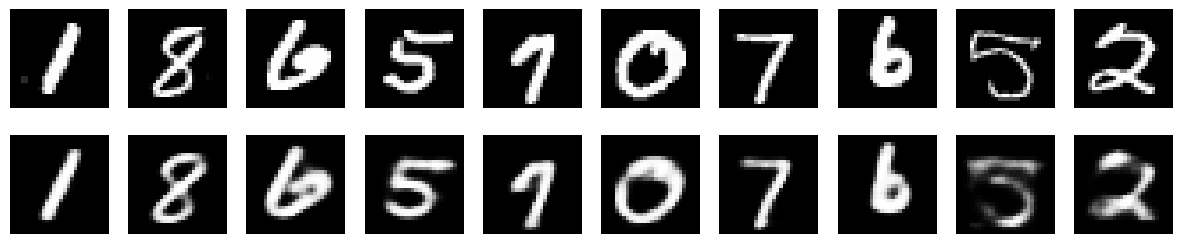

In [13]:
vae.eval()
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, input_dim)
    x_hat, _, _ = vae(x)
    x = x.view(-1, 28, 28)
    x_hat = x_hat.view(-1, 28, 28)

    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axs[0, i].imshow(x[i].cpu().numpy(), cmap='gray')
        axs[1, i].imshow(x_hat[i].cpu().numpy(), cmap='gray')
        axs[0, i].axis('off')
        axs[1, i].axis('off')
    plt.show()



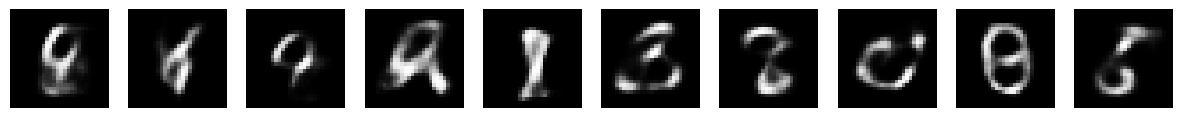

In [15]:
# visualizing generated samples 
with torch.no_grad():
    z = torch.randn(10, latent_dim)
    sample = vae.decoder(z)
    sample = sample.view(-1, 28, 28)

    fig, axs = plt.subplots(1, 10, figsize=(15, 3))
    for i in range(10):
        axs[i].imshow(sample[i].cpu().numpy(), cmap='gray')
        axs[i].axis('off')
    plt.show()


## c. GANs Implementation using pytorch

In [7]:
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.main = nn.Sequential(
            nn.Linear(noise_dim, 7*7*256),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7,7)),
            nn.ConvTranspose2d(256, 128, 5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
            nn.Flatten(),
            nn.Linear(7*7*128, 1)
        )

    def forward(self, x):
        return self.main(x)

In [9]:
NOISE_DIM = 100

generator = Generator(NOISE_DIM)
discriminator = Discriminator()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = generator.to(device)
discriminator = discriminator.to(device)

In [12]:
# Set Loss Function, optimizers and Hyperparameter 
criterion = nn.BCEWithLogitsLoss()

generator_optimizer = optim.Adam(
    generator.parameters(), lr=0.0002, betas=(0.5, 0.999)
)
descriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999)
)
NUM_EPOCHS = 1
BATCH_SIZE = 256

In [13]:
# Prepare DataLoader 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)

# training Process
for epoch in range(NUM_EPOCHS):
    for i, data in enumerate(train_loader):
        real_images, _ = data 
        real_images = real_images.to(device)

        descriminator_optimizer.zero_grad()
        real_labels = torch.ones(real_images.size(0), 1, device=device)
        real_outputs = discriminator(real_images)
        real_loss = criterion(real_outputs, real_labels)
        real_loss.backward()

        noise = torch.randn(real_images.size(0), NOISE_DIM, device=device)
        fake_images = generator(noise)
        fake_labels = torch.zeros(real_images.size(0), 1, device=device)
        fake_outputs = discriminator(fake_images.detach())
        fake_loss = criterion(fake_outputs, fake_labels)
        fake_loss.backward()
        descriminator_optimizer.step()

        generator_optimizer.zero_grad()
        fake_labels = torch.ones(real_images.size(0), 1, device =device)
        fake_outputs = discriminator(fake_images)
        gen_loss = criterion(fake_outputs, fake_labels)
        generator_optimizer.step()

        if i % 100 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{len(train_loader)}], '
                  f'Discriminator Loss: {real_loss.item() + fake_loss.item():.4f}, '
                  f'Generator Loss: {gen_loss.item():.4f}')

Epoch [1/1], Step [1/235], Discriminator Loss: 0.0037, Generator Loss: 7.5182
Epoch [1/1], Step [101/235], Discriminator Loss: 0.0000, Generator Loss: 13.7713
Epoch [1/1], Step [201/235], Discriminator Loss: 0.0000, Generator Loss: 15.0435


D. GANS Implementation using Tensorflow

In [ ]:
import tensorflow as tf
import numpy as np
import keras.layers as layers

# Load and preprocess MNIST (minimal)
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0  # Normalize to [0, 1]
x_train = x_train.reshape(-1, 784)  # Flatten to (batch_size, 784)

# Generator: simple architecture
latent_dim = 50
generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(latent_dim,)),
    layers.Dense(784, activation='sigmoid')  # Output 28*28=784
])

# Discriminator: simple architecture
discriminator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# GAN: combine models
discriminator.trainable = False
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training loop: minimal
batch_size = 64
for epoch in range(2):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx]
    noise = np.random.randn(batch_size, latent_dim)
    fake = generator(noise, training=False)
    
    # Train discriminator
    d_loss = 0.5 * (discriminator.train_on_batch(real, np.ones((batch_size, 1))) +
                    discriminator.train_on_batch(fake, np.zeros((batch_size, 1))))
    
    # Train generator
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))
    
    print(f"Epoch {epoch+1}/2 - D loss: {d_loss:.4f}, G loss: {g_loss:.4f}")

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2 - D loss: 0.6220, G loss: 0.4145
Epoch 2/2 - D loss: 0.7427, G loss: 0.3836


In [2]:
import tensorflow as tf
import numpy as np
from keras import layers

(x_train, _),_ = tf.keras.datasets.mnist.load_data()

In [7]:
# data preprocessing
x_train = x_train.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28*28)

In [8]:
# Generator 
latent_dim = 50 
generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(latent_dim, )), 
    layers.Dense(784, activation='sigmoid')
])

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Discriminator 
discriminator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784, )),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Combine Models 
discriminator.trainable = False 
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

In [11]:
# training 
batch_size = 64
for epoch in range(2):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx] 
    noise = np.random.randn(batch_size, latent_dim)
    fake = generator(noise, training=False)

    # train discriminator 
    d_loss = 0.5 * (discriminator.train_on_batch(real, np.ones((batch_size, 1)))+ discriminator.train_on_batch(fake, np.zeros((batch_size, 1))))

    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    print(f"Epoch {epoch+1}/2 - D loss: {d_loss:.4f}, G loss: {g_loss:.4f}")

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/2 - D loss: 0.8022, G loss: 0.8199
Epoch 2/2 - D loss: 0.7712, G loss: 0.7703


## d. Conditional GAN implementation using Tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model 
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.datasets import cifar10 
from keras.preprocessing import image 
import keras.backend as K
import matplotlib.pyplot as plt 
import numpy as np
import time 
from tqdm import tqdm 

In [3]:
# Loading Dataset and Declaring Variables
batch_size = 16
epoch_count = 3
noise_dim = 100
n_class = 10
tags = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog','Horse', 'Ship', 'Truck']
img_size = 32

(X_train, y_train),(_, _) = cifar10.load_data()

X_train = (X_train - 127.5)/ 127.5

dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(buffer_size=1000).batch(batch_size)

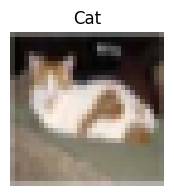

In [4]:
plt.figure(figsize=(2, 2))
idx = np.random.randint(0, len(X_train))
img = image.array_to_img(X_train[idx], scale=True)
plt.imshow(img)
plt.axis('off')
plt.title(tags[y_train[idx][0]])
plt.show()

In [5]:
# Defining Loss Function and Optimizers
bce_loss = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real, fake):
    real_loss = bce_loss(tf.ones_like(real), real)
    fake_loss = bce_loss(tf.zeros_like(fake), fake)
    total_loss = real_loss + fake_loss
    return total_loss 

def generator_loss(preds):
    return bce_loss(tf.ones_like(preds), preds)

d_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

In [9]:
# Building the Generator Model 
def build_generator():
    in_label = tf.keras.layers.Input(shape=(1,))
    li = tf.keras.layers.Embedding(n_class, 50)(in_label)

    n_nodes = 8*8
    li = tf.keras.layers.Dense(n_nodes)(li)
    li = tf.keras.layers.Reshape((8, 8, 1))(li)
    in_lat = tf.keras.layers.Input(shape=(noise_dim,))

    n_nodes = 128*8*8
    gen = tf.keras.layers.Dense(n_nodes)(in_lat)
    gen = tf.keras.layers.LeakyReLU(alpha=0.2)(gen)
    gen = tf.keras.layers.Reshape((8, 8, 128))(gen)
    merge = tf.keras.layers.Concatenate()([gen, li])

    gen = tf.keras.layers.Conv2DTranspose(128, (4, 4), strides=(2,2), padding='same')(merge)
    gen = tf.keras.layers.LeakyReLU(alpha=0.2)(gen)
    gen = tf.keras.layers.Conv2DTranspose(128, (4,4), strides=(2,2 ), padding='same')(gen)
    gen = tf.keras.layers.LeakyReLU(alpha=0.2)(gen)
    out_layer= tf.keras.layers.Conv2D(3, (8,8), activation='tanh', padding='same')(gen)
    model = Model([in_lat, in_label], out_layer)
    return model 

g_model = build_generator()
g_model.summary()

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8192)      │    827,392 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 50)     │        500 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 8192)      │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 64)     │      3,264 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 8, 8, 128) │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 8, 8, 1)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 129) │          0 │ reshape_6[0][0],  │
│ (Concatenate)       │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 16, 16,    │    264,320 │ concatenate_2[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 32, 32,    │    262,272 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32, 3) │     24,579 │ leaky_re_lu_8[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,382,327 (5.27 MB)

 Trainable params: 1,382,327 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def build_discriminator():
    in_label = tf.keras.layers.Input(shape=(1,))
    li = tf.keras.layers.Embedding(n_class, 50)(in_label)
    n_nodes = img_size * img_size 
    li = tf.keras.layers.Dense(n_nodes)(li)
    li = tf.keras.layers.Reshape((img_size, img_size, 1))(li)

    in_image = tf.keras.layers.Input(shape=(img_size, img_size, 3))
    
    merge = tf.keras.layers.Concatenate()([in_image, li])

    fe = tf.keras.layers.Conv2D(128, (3,3), strides=(2,2), padding='same')(merge)
    fe = tf.keras.layers.LeakyReLU(alpha=0.2)(fe)

    fe = tf.keras.layers.Conv2D(128, (3,3), strides=(2,2), padding='same')(fe)
    fe = tf.keras.layers.LeakyReLU(alpha=0.2)(fe)

    fe = tf.keras.layers.Flatten()(fe)

    fe = tf.keras.layers.Dropout(0.4)(fe)

    out_layer = tf.keras.layers.Dense(1, activation='sigmoid')(fe)
    model = Model([in_image, in_label], out_layer)

    return model

d_model =build_discriminator()
d_model.summary()

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 50)     │        500 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1, 1024)   │     52,224 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 32, 32, 1) │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32, 4) │          0 │ input_layer_9[0]… │
│ (Concatenate)       │                   │            │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │      4,736 │ concatenate_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ leaky_re_lu_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 8, 8, 128) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ leaky_re_lu_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8192)      │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │      8,193 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 213,237 (832.96 KB)

 Trainable params: 213,237 (832.96 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Creating Training Step Function

@tf.function
def train_step(dataset):
    real_images, real_labels = dataset 

    random_latent_vectors = tf.random.normal(shape=(batch_size, noise_dim))
    generated_images = g_model([random_latent_vectors, real_labels])

    with tf.GradientTape() as tape:
        pred_fake = d_model([generated_images, real_labels])
        pred_real = d_model([real_images, real_labels])

        d_loss = discriminator_loss(pred_real, pred_fake)

    grads = tape.gradient(d_loss, d_model.trainable_variables)

    d_optimizer.apply_gradients(zip(grads, d_model.trainable_variables))

    random_latent_vectors = tf.random.normal(shape=(batch_size, noise_dim))

    with tf.GradientTape() as tape:
        fake_images = g_model([random_latent_vectors, real_labels])
        predictions= d_model([fake_images, real_labels])
        g_loss = generator_loss(predictions) 

    grads = tape.gradient(g_loss, g_model.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, g_model.trainable_variables))

    return d_loss, g_loss

In [12]:
# visualizing Generated images

def show_samples(num_samples, n_class, g_model):
    fig, axes = plt.subplots(10, num_samples, figsize=(10, 20))
    fig.tight_layout()
    fig.subplots_adjust(wspace=None, hspace=0.2)

    for l in np.arange(10):
        random_noise = tf.random.normal(shape=(num_samples, noise_dim))
        label = tf.ones(num_samples)*l
        generated_images = g_model.predict([random_noise, label])
        for j in range(generated_images.shape[0]):
            img= image.array_to_img(generated_images[j], scale=True)
            axes[l, j].imshow(img)
            axes[l, j].yaxis.set_ticks([])
            axes[l, j].xaxis.set_ticks([])

            if j == 0:
                axes[l, j].set_ylabel(tags[l])
        plt.show()

Epoch 3


100%|██████████| 3125/3125 [10:39<00:00,  4.89it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


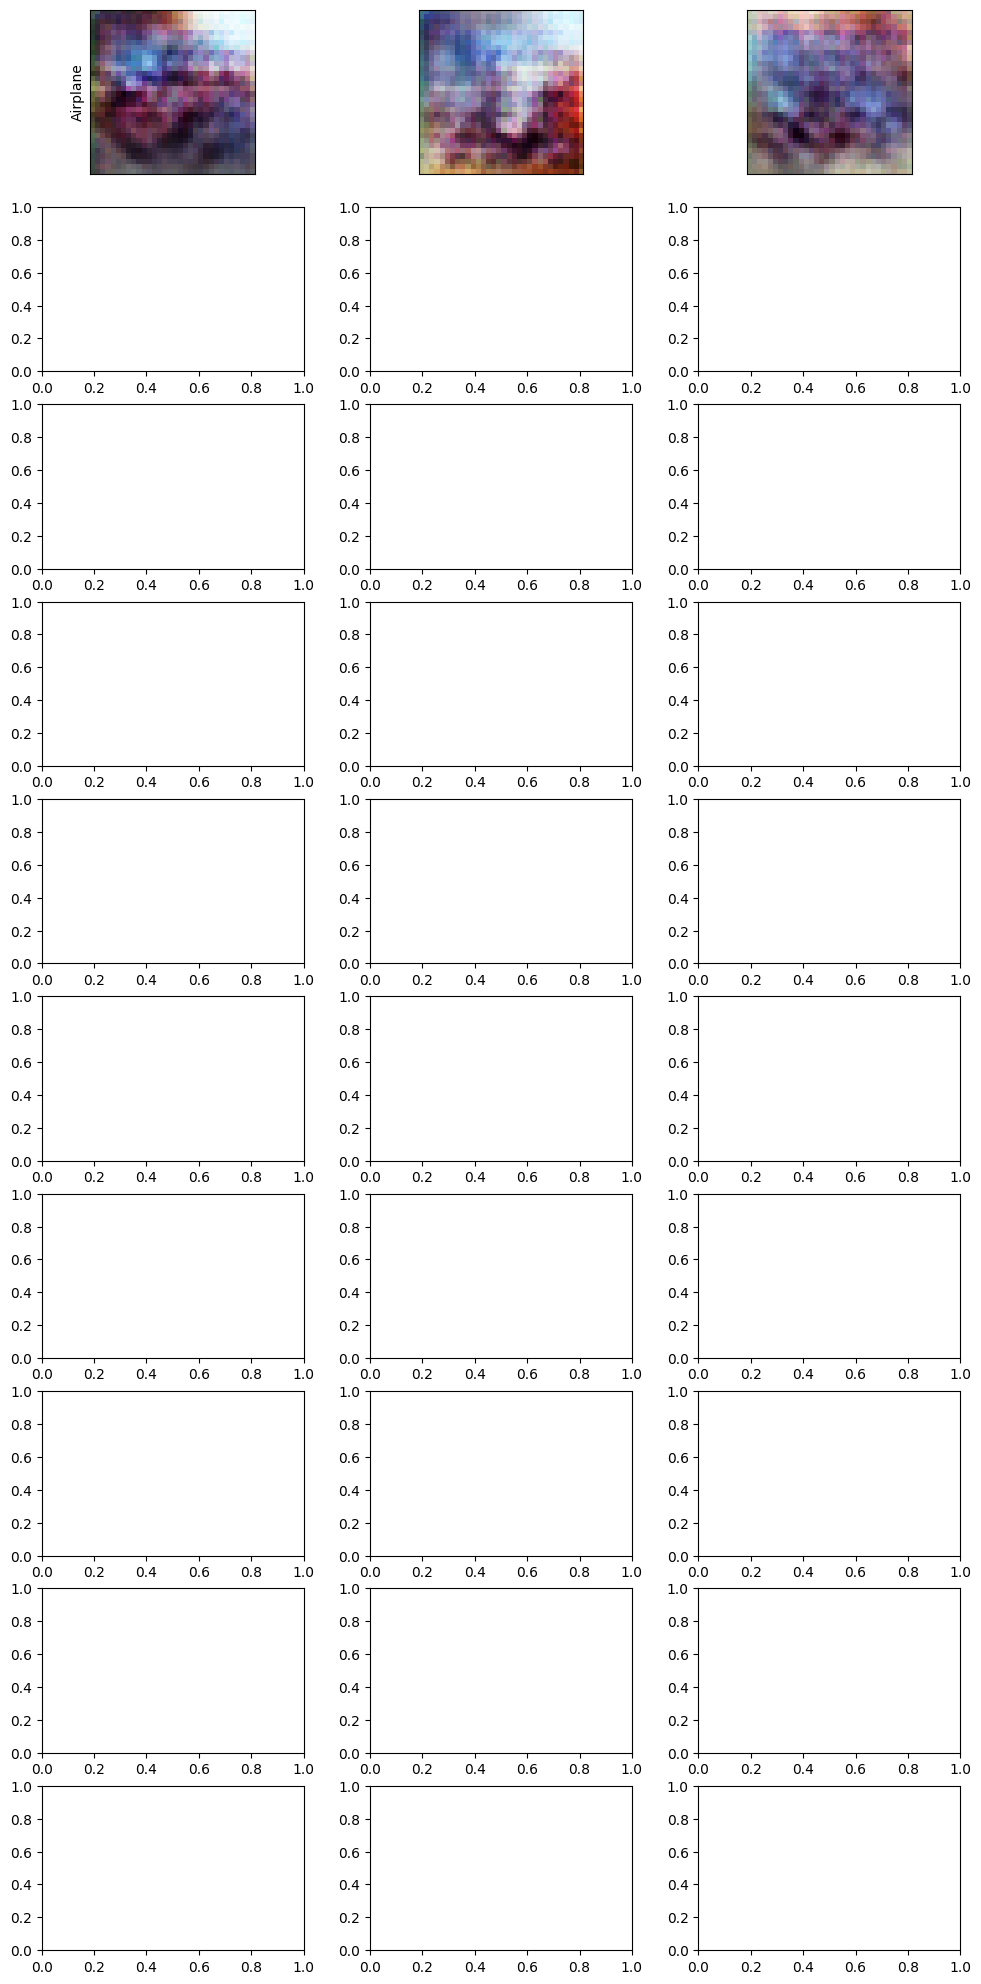

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch: 0 -- Generator Loss: 0.9103618860244751, Discriminator Loss: 1.2772636413574219

Took 641.1389570236206 seconds. 


Epoch 3


100%|██████████| 3125/3125 [11:15<00:00,  4.62it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


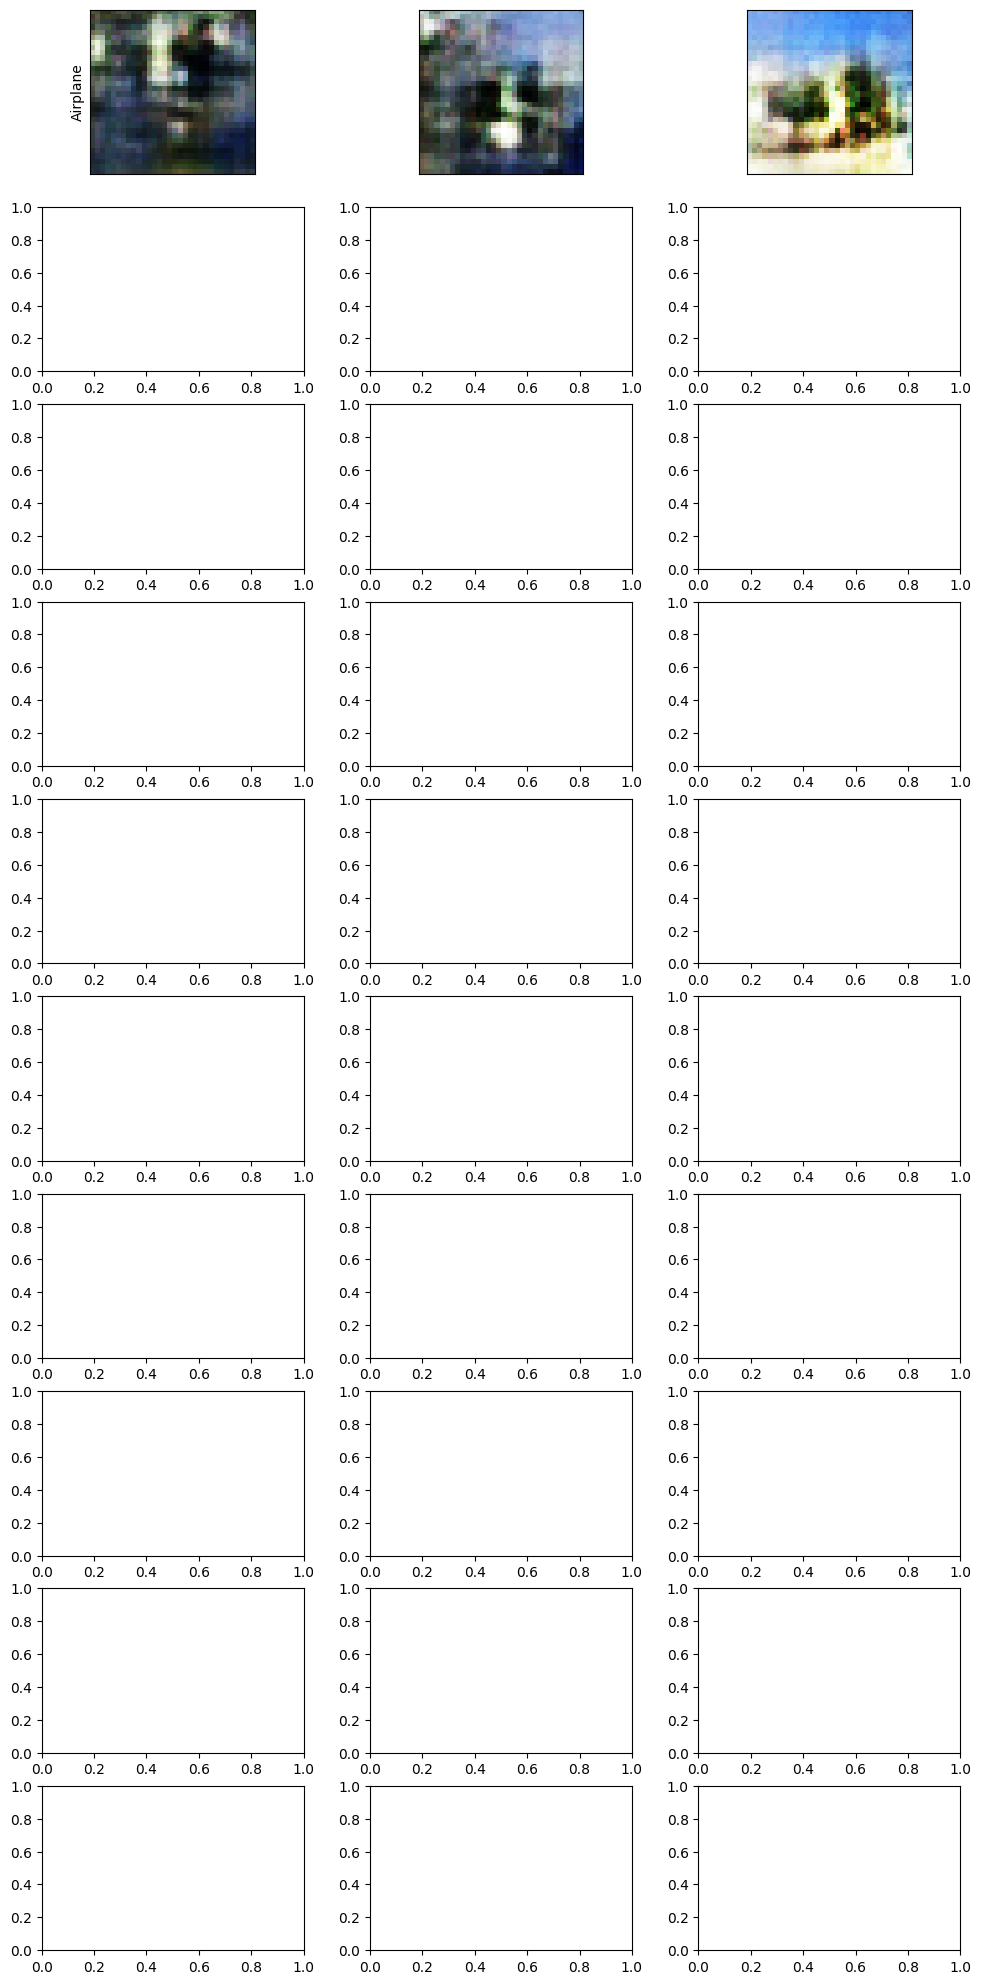

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Epoch: 1 -- Generator Loss: 0.8397076725959778, Discriminator Loss: 1.3152369260787964

Took 677.4044301509857 seconds. 


Epoch 3


100%|██████████| 3125/3125 [11:55<00:00,  4.37it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


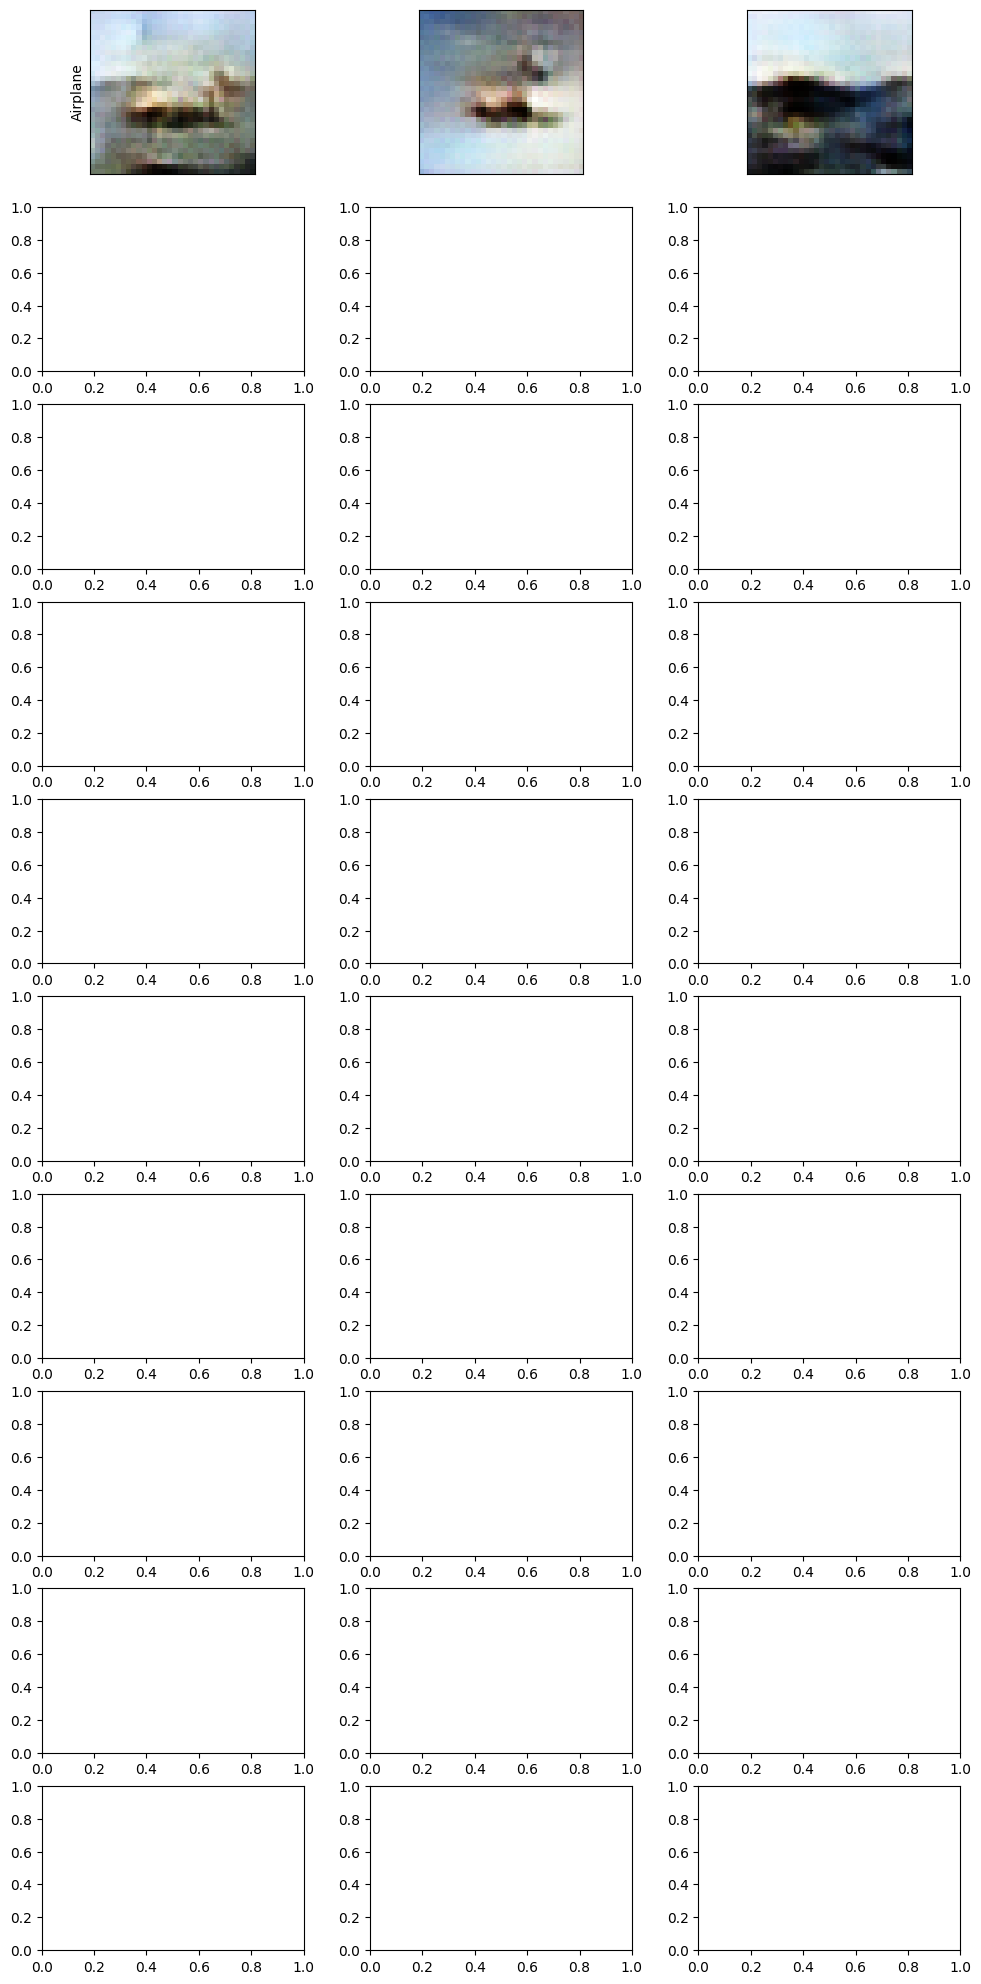

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch: 2 -- Generator Loss: 0.8023920059204102, Discriminator Loss: 1.340304970741272

Took 717.1881358623505 seconds. 




In [13]:
def train(dataset, epochs=epoch_count):

    for epoch in range(epochs):
        print('Epoch', epochs)
        d_loss_list = []
        g_loss_list = []
        q_loss_list = []
        start = time.time()

        itern = 0
        for image_batch in tqdm(dataset):
            d_loss, g_loss = train_step(image_batch)
            d_loss_list.append(d_loss)
            g_loss_list.append(g_loss)
            itern = itern+1

        show_samples(3, n_class, g_model)

        print(f'Epoch: {epoch} -- Generator Loss: {np.mean(g_loss_list)}, Discriminator Loss: {np.mean(d_loss_list)}\n')
        print(f'Took {time.time() - start} seconds. \n\n')

train(dataset, epochs = epoch_count)


## e. WGAN Implementation using Tensorflow

In [1]:
from numpy import expand_dims
from numpy import mean 
from numpy import ones 
from numpy.random import randn 
from numpy.random import randint 
from keras.datasets.mnist import load_data 
from keras import backend 
from keras.optimizers import RMSprop
from keras.models import Sequential 
from keras.layers import Dense 
from keras.layers import Reshape 
from keras.layers import Flatten
from keras.layers import Conv2D 
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization 
from keras.initializers import RandomNormal
from keras.constraints import Constraint
import matplotlib.pyplot as plt 
import tensorflow as tf 

In [2]:
# Define Wasserstein loss Function
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

In [4]:
# Generate images
def load_real_samples():
    (trainX, trainy), (_,_) = load_data()
    seleted_ix = trainy == 5
    X = trainX[seleted_ix]
    X = expand_dims(X, axis=-1)
    X = X.astype('float32')
    X = (X - 127.5)/127.5
    return X 

# select real samples 
def generate_real_samples(dataset, n_samples):
    ix = randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = -ones((n_samples, 1))
    return X, y

In [5]:
# Define Critic and Discriminator Model
# clip model 
class ClipConstraint(Constraint):
    def __init__(self, clip_value):
        self.clip_value = clip_value
    def __call__(self, weights):
        return backend.clip(weights, -self.clip_value, self.clip_value)

In [8]:
def define_critic(in_shape=(28, 28, 1)):
    init = RandomNormal(stddev=0.02)
    const = ClipConstraint(0.01)
    model = Sequential()
    model.add(Conv2D(64, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init, kernel_constraint=const, input_shape=in_shape))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(64, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init, kernel_constraint=const))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Flatten())
    model.add(Dense(1))
    opt = RMSprop(learning_rate=0.00005)
    model.compile(loss=wasserstein_loss, optimizer=opt)
    return model 

In [31]:
def define_generator(latent_dim):
    init = RandomNormal(stddev=0.03)
    model = Sequential()
    
    # First dense layer
    n_nodes = 128 * 7 * 7
    model.add(Dense(n_nodes, kernel_initializer=init, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((7, 7, 128)))  # Reshape to 4D tensor
    
    # First upsampling block: 7x7 -> 14x14
    model.add(Conv2DTranspose(128, (4, 4), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    
    # Second upsampling block: 14x14 -> 28x28
    model.add(Conv2DTranspose(128, (4, 4), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    
    # Output layer
    model.add(Conv2D(1, (7, 7), activation='tanh', padding='same', kernel_initializer=init))
    
    return model

In [32]:
# Update the generator
def define_gan(generator, critic):
    for layer in critic.layers:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = False 
    model = Sequential()
    model.add(generator)
    model.add(critic)
    opt = RMSprop(learning_rate=0.00005)
    model.compile(loss=wasserstein_loss, optimizer=opt)
    return model 

In [33]:
# Generate Fake Samples 
def generate_latent_points(latent_dim, n_samples):
    x_input = randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input 

def generate_fake_samples(generator, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    X = generator.predict(x_input)
    y = ones((n_samples, 1))
    return (X, y)

In [34]:
# Model Training 
def train(g_model, c_model, gan_model, dataset, latent_dim, n_epochs=3, n_batch=64, n_critics=5):
    bat_per_epo = int(dataset.shape[0] / n_batch)
    n_steps = bat_per_epo * n_epochs 
    half_batch = int(n_batch / 2)

    c1_hist, c2_hist, g_hist = list(), list(), list()

    for i in range(n_steps):
        c1_tmp, c2_tmp = list(), list()
        for _ in range(n_critics):
            X_real, y_real = generate_real_samples(dataset, half_batch)
            c_loss1 = c_model.train_on_batch(X_real, y_real)
            c1_tmp.append(c_loss1)
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
            c_loss2 = c_model.train_on_batch(X_fake, y_fake)
            c2_tmp.append(c_loss2)
        c1_hist.append(mean(c1_tmp))
        c2_hist.append(mean(c2_tmp))
        X_gan = generate_latent_points(latent_dim, n_batch)
        y_gan = -ones((n_batch, 1))
        g_loss = gan_model.train_on_batch(X_gan, y_gan)
        g_hist.append(g_loss)
        print('&gt:%d, c1=%.3f, c2=%.3f, g=%.3f' % (i+1,c1_hist[-1], c2_hist[-1], g_loss))
        if (i+1) % bat_per_epo == 0:
            summarize_performance(i, g_model, latent_dim)
        
    plot_history(c1_hist, c2_hist, g_hist)

In [35]:
def summarize_performance(step, g_model, latent_dim, n_samples=10):
    X, _ = generate_fake_samples(g_model, latent_dim, n_samples)
    X = (X + 1) / 2.0 
    for i in range(10*10):
        plt.subplot(10, 10, 1 + i)
        plt.axis('off')
        plt.imshow(X[i, :, :, 0], cmap='gray_r')
    filename1 = 'plot_%04d.png' % (step+1)
    plt.savefig(filename1)
    plt.close()

def plot_history(d1_hist, d2_hist, g_hist):
    plt.plot(d1_hist, label='crit_real')
    plt.plot(d2_hist, label='crit_fake')
    plt.plot(g_hist, label='gen')
    plt.legend()
    plt.savefig('line_plot_loss.png')
    plt.close()

(5421, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
&gt:1, c1=-0.800, c2=-0.778, g=0.645
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
&gt:2, c1=-0.683, c2=-0.630, g=0.177
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
&gt:3, c1=-0.490, c2=-0.444, g=-0.169
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
&gt:4, c1=-0.342, c2=-0.306, g=-0.468
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/

IndexError: index 10 is out of bounds for axis 0 with size 10

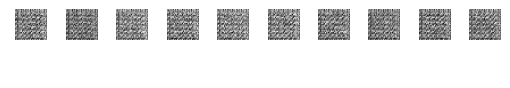

In [36]:
latent_dim = 50
critic = define_critic()
generator = define_generator(latent_dim)
gan_model = define_gan(generator, critic)
dataset = load_real_samples()
print(dataset.shape)
train(generator, critic, gan_model, dataset, latent_dim)

In [ ]:
# Print working directory and contents
print(f"Current working directory: {os.getcwd()}")
print(f"Directory contents: {os.listdir('.')}")

Current working directory: /Users/orbinsunny/Documents/GitHub/Machine_Learning/Deep_Learning/GANs
Directory contents: ['gan.ipynb', 'content', 'practice.ipynb', '.gitignore', 'data', 'test.ipynb', 'generative_models.ipynb']


In [ ]:
import os

# Define the image directory - modify this path to match your project structure
imgdir = "./images"  # or use absolute path like "/path/to/your/images"

# Create directory if it doesn't exist
os.makedirs(imgdir, exist_ok=True)

try:
    # List GIF files that start with 'plot_'
    gif_files = [file for file in os.listdir(imgdir) if file.startswith('plot_')]
except FileNotFoundError:
    print(f"Directory {imgdir} not found")
    gif_files = []